In [3]:
import pandas as pd

# Load original dataset
df = pd.read_csv("hospital_1.csv")

# Depression-related questions from DASS
DASS_keys = {'Depression': [3, 5, 10, 13, 16, 17, 21, 24, 26, 31, 34, 37, 38, 42]}
Dep_cols = ['Q' + str(i) + 'A' for i in DASS_keys['Depression']]

# Ensure values are numeric and subtract 1 (as per DASS instructions)
df[Dep_cols] = df[Dep_cols].apply(pd.to_numeric, errors='coerce') - 1

# Calculate total depression score
df['Total_Count'] = df[Dep_cols].sum(axis=1)

# Define condition levels
def condition(x):
    if x <= 9:
        return 'Normal'
    elif 10 <= x <= 13:
        return 'Mild'
    elif 14 <= x <= 20:
        return 'Moderate'
    elif 21 <= x <= 27:
        return 'Severe'
    else:
        return 'Extremely Severe'

# Add Condition column
df['Condition'] = df['Total_Count'].apply(condition)

# Drop rows with missing values in Condition
df = df.dropna(subset=['Condition'])

df.head()


,full_name,email,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,...,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,Total_Count,Condition
0,Julie Miller,liutracy@example.com,University degree,Urban,Female,No,Small screen,Unique network,Right,Muslim,...,2,7,4,6,4,7,2,7,33,Extremely Severe
1,Amy Serrano,jason26@example.net,High school,Suburban,Male,No,Small screen,Shared network,Right,Muslim,...,1,7,1,7,7,7,3,7,34,Extremely Severe
2,David Farrell,kevinwebb@example.com,High school,Suburban,Female,Yes,Small screen,Unique network,Right,Christian (Catholic),...,1,1,1,1,4,4,3,3,39,Extremely Severe
3,Albert Freeman,laurabrooks@example.com,Less than high school,Suburban,Male,No,Small screen,Unique network,Right,Christian (Catholic),...,4,4,5,5,5,5,5,4,4,Normal
4,Nicole Pittman,tammy83@example.com,High school,Urban,Female,No,Big screen,Unique network,Right,Christian (Mormon),...,7,7,4,7,7,5,2,2,41,Extremely Severe


In [4]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
target_column = 'Condition'
label_encoders = {}

# Encode all object (categorical) columns except target
for col in df_encoded.select_dtypes(include='object').columns:
    if col != target_column:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le

# Encode target column
le_target = LabelEncoder()
df_encoded[target_column] = le_target.fit_transform(df_encoded[target_column])


In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df_encoded.drop(columns=['Condition'])
y = df_encoded['Condition']

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)



In [6]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train_sm.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_sm, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Define MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(input_dim=X.shape[1], num_classes=len(le_target.classes_)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



In [7]:
# Training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")


Epoch 1 | Loss: 1947.2289
Epoch 2 | Loss: 536.4747
Epoch 3 | Loss: 492.1062
Epoch 4 | Loss: 418.1196
Epoch 5 | Loss: 389.4352
Epoch 6 | Loss: 362.1545
Epoch 7 | Loss: 303.7501
Epoch 8 | Loss: 281.8798
Epoch 9 | Loss: 241.6069
Epoch 10 | Loss: 246.6030


✅ Validation Accuracy: 0.7891

📊 Classification Report (Validation):
                  precision    recall  f1-score   support

Extremely Severe       0.92      0.93      0.92       880
            Mild       0.70      0.53      0.60       243
        Moderate       0.57      0.92      0.70       472
          Normal       0.96      0.92      0.94       568
          Severe       0.66      0.31      0.42       412

        accuracy                           0.79      2575
       macro avg       0.76      0.72      0.72      2575
    weighted avg       0.80      0.79      0.78      2575


🧠 Training Accuracy: 0.7389

📊 Classification Report (Training):
                  precision    recall  f1-score   support

Extremely Severe       0.87      0.94      0.91      3518
            Mild       0.82      0.66      0.73      3518
        Moderate       0.53      0.89      0.66      3518
          Normal       0.85      0.93      0.89      3518
          Severe       0.82      0.28      0.41  

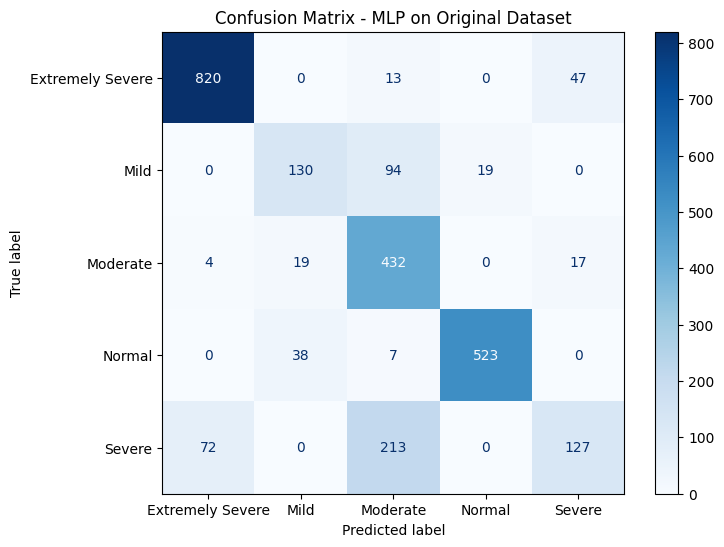

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
model.eval()
with torch.no_grad():
    # Predict on validation set
    y_val_pred = model(X_val_tensor.to(device))
    y_val_pred_labels = torch.argmax(y_val_pred, dim=1).cpu().numpy()

    # Predict on training set
    y_train_pred = model(X_train_tensor.to(device))
    y_train_pred_labels = torch.argmax(y_train_pred, dim=1).cpu().numpy()

# Validation Metrics
val_acc = accuracy_score(y_val, y_val_pred_labels)
print(f"✅ Validation Accuracy: {val_acc:.4f}")
print("\n📊 Classification Report (Validation):")
print(classification_report(y_val, y_val_pred_labels, target_names=[str(c) for c in le_target.classes_]))

# Training Metrics
train_acc = accuracy_score(y_train_sm, y_train_pred_labels)
print(f"\n🧠 Training Accuracy: {train_acc:.4f}")
print("\n📊 Classification Report (Training):")
print(classification_report(y_train_sm, y_train_pred_labels, target_names=[str(c) for c in le_target.classes_]))

# Confusion Matrix for Validation
cm = confusion_matrix(y_val, y_val_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - MLP on Original Dataset")
plt.show()
